# 0.准备各种包

In [1]:
import os
import typing
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import math
import scipy.stats
from scipy.stats import gaussian_kde, variation
from scipy.stats import pearsonr
import sys
from PIL import Image

In [2]:
from collections import defaultdict

In [3]:
import glob

In [4]:
import pickle

In [5]:
import re


In [6]:
%matplotlib inline

In [7]:
default_pal = sns.color_palette()

In [8]:
from scipy.stats import gaussian_kde, pearsonr

In [9]:
%config InlineBackend.figure_format = 'retina'

In [10]:
from scipy import stats
import numpy as np
from scipy.stats import mannwhitneyu

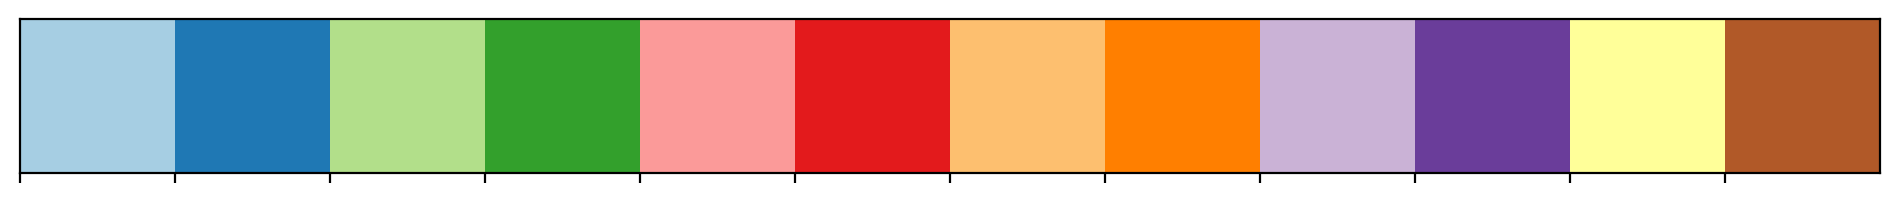

In [11]:
# setting color palette
import seaborn as sns
pal = sns.color_palette('Paired')
#pal = [pal[i] for i in (0,1, 6,7, 8 ,9,2 ,3)]
#pal = [pal[i] for i in (1, 7, 9 ,3)]
sns.set_palette(pal)
sns.palplot(pal)


In [13]:
from Bio import SeqIO
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## 1 只计算AAUAAA的变体

In [435]:
def generate_single_mismatch_variants(motif):
    bases = ['A', 'U', 'G', 'C']
    variants = set()
    for i in range(len(motif)):
        for b in bases:
            if b != motif[i]:
                variant = motif[:i] + b + motif[i+1:]
                if variant != 'AAAAAA':
                    variants.add(variant)
    return variants

motif = 'AAUAAA'
motif_variants = generate_single_mismatch_variants(motif)
motif_variants.add(motif)

In [437]:
data_dir = "/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal"
species_dirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

result_dict = defaultdict(lambda: defaultdict(float))

for species in species_dirs:
    species_dir = os.path.join(data_dir, species)
    # 找到*up40_down10.fa文件
    fasta_files = glob.glob(os.path.join(species_dir, "*up40_down10.fa"))
    if not fasta_files:
        print(f"Warning: No up40_down10.fa found for {species}")
        continue
    
    fasta_file = fasta_files[0]
    with open(fasta_file) as f:
        sequences = [line.strip().upper().replace('T', 'U') for line in f if line.strip()]

    total_seqs = len(sequences)
    if total_seqs == 0:
        continue

    for variant in motif_variants:
        count = sum(1 for seq in sequences if variant in seq)
        proportion = count / total_seqs
        result_dict[species][variant] = proportion

# 转成DataFrame
df = pd.DataFrame(result_dict).T.fillna(0)
df.index.name = "Species"

# 按AAUAAA及变体排序列
motif_cols = [motif] + sorted([m for m in motif_variants if m != motif])
df = df[motif_cols]

# 输出结果表格
df.to_csv("polyA_signal_motif_proportion.tsv", sep='\t')
print("Proportion table saved as polyA_signal_motif_proportion.tsv")


#print("Stacked bar plot saved as polyA_signal_motif_proportion_stackedbar.pdf")

Proportion table saved as polyA_signal_motif_proportion.tsv


In [438]:
mapped={"01.cucumber":"Cucumis sativus",
"02.phalaenopsis":"Phalaenopsis equestris",
"03.chlamydomonas":"Chlamydomonas reinhardtii",
"04.adiantum":"Adiantum caplillusveneris",
"05.physcomitrium":"Physcomitrium patens",
"07.selaginella":"Selaginella moellendorffii",
"08.macadamia":"Macadamia integrifolia",
"09.nymphaea":"Nymphaea colorata",
"10.solanum":"Solanum lycopersicum",
"11.lactuca":"Lactuca sativa",
"12.beta":"Beta vulgaris",
"13.vitis":"Vitis vinifera",
"14.impatiens":"Impatiens glandulifera",
"15.cycas":"Cycas panzhihuaensis",
"16.magnolia":"Magnolia biondii",
"19.cycas_debao":"Cycas debaoensis",
"20.arabidopsis":"Arabidopsis thaliana",
"21.soybean":"Glycine max",
"22.maize":"Zea mays",
"23.rice":"Oryza sativa"}

In [439]:
# 转成DataFrame
df = pd.DataFrame(result_dict).T.fillna(0)
df.index.name = "Species"
df.index = df.index.to_series().replace(mapped)
df.index = (
    df.index.to_series()
             .str.split()
             .apply(lambda x: (x[0][0] + x[1][:2]) if len(x) >= 2 else x[0][:3])
             .str.capitalize()
)
species_order = ['Cre', 'Ppa', 'Smo', 'Aca', 'Cpa', 'Cde', 'Nco', 'Mbi', 'Peq', 'Zma', 'Osa', 'Min', 'Vvi', 'Ath', 'Gma', 'Csa', 'Bvu', 'Igl', 'Sly', 'Lsa']
df=df.reindex(species_order)

In [440]:
kmer_order = [ 'AAUAAA', 'AAUAUA','AAUAAU','AACAAA','AUUAAA', 'UAUAAA', 'AAUAAC', 'ACUAAA','AGUAAA', 'AAUACA',
       'AAUUAA', 'AAUAGA', 'AAGAAA', 'AAUCAA', 
       'AAUGAA', 'CAUAAA', 'AAUAAG', 'GAUAAA']
# Reorder the DataFrame columns
df = df[kmer_order]

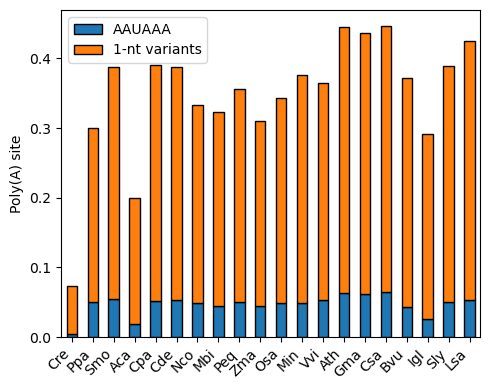

In [441]:
# 重新组合成2列：AAUAAA 和 "1-nt variants"（其余都加总）
df_final = pd.DataFrame()
df_final["AAUAAA"] = df["AAUAAA"]
df_final["1-nt variants"] = df.drop(columns=["AAUAAA"]).sum(axis=1)

# 画堆积柱状图
ax = df_final.plot(kind="bar", stacked=True, color=["#1f77b4", "#ff7f0e"], figsize=(5, 4), edgecolor="black")
plt.ylabel("Poly(A) site")
plt.xlabel("")
plt.title("")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.rcParams['svg.fonttype']='none'
#plt.savefig("/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/figure/all_AAUAAA.svg", dpi=300, bbox_inches='tight',format='svg')
plt.show()

## 2 -100~+50

In [ ]:
# 目录路径
base_dir = "/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal"
subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# 定义motif
canonical = "AAUAAA"
ugua = "UGUA"
ua = "UA"
variant_set = generate_variants(canonical)


for subdir in subdirs:
    fasta_path = glob.glob(os.path.join(base_dir, subdir, "*.polya_site.up250_down150.fa"))
    if not fasta_path:
        continue
    sample = subdir  # 或者使用 os.path.basename(fasta_path[0]) 更精细

    # 读取序列
    sequences = read_fasta(fasta_path[0])
    if not sequences:
        continue

    # 计算 motif 密度
    density_dict = {
        "AAUAAA": count_motif_density(sequences, {canonical}, 6),
        "1-nt variants": count_motif_density(sequences, variant_set, 6),
        "UGUA": count_motif_density(sequences, {ugua}, 4),
        "UA": count_motif_density(sequences, {"UA"}, 2),
    }

    # 统一长度
    min_len = min(len(d) for d in density_dict.values())
    x = np.arange(-250, -250 + min_len)
    mask = (x >= -100) & (x <= 50)
    x_trimmed = x[mask]
    df_density = pd.DataFrame({"Position": x_trimmed})
    for motif, arr in density_dict.items():
        df_density[motif] = np.array(arr[:min_len])[mask]
    df_density['species'] = sample

    # 保存为 txt（tab 分隔）
    out_path = os.path.join(base_dir, subdir, f"{subdir}.up100_down50.txt")
    df_density.to_csv(out_path, sep='\t', index=False)

    plt.figure(figsize=(5, 3))
    for label, density in density_dict.items():
        plt.plot(x_trimmed, np.array(density[:min_len])[mask], label=label)
    plt.axvline(0, color="gray", linestyle="--", lw=1)
    plt.xlabel("Position relative to poly(A) site")
    plt.ylabel("Motif frequency per position")
    plt.title(sample)
    plt.legend()
    plt.tight_layout()
    #plt.savefig(f"/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/figure/{sample}.png", dpi=300, bbox_inches='tight') 
    plt.show()

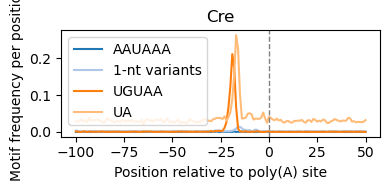

In [413]:
#单独处理绿藻 UGUAA

fasta_file = "/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/03.chlamydomonas/03.chlamydomonas.polya_site.up250_down150.fa"
sequences = read_fasta(fasta_file)

# 定义motif
canonical = "AAUAAA"
uguaa = "UGUAA"
ua = "UA"
variant_set = generate_variants(canonical)

# 分析四种motif分布
density_dict = {
    "AAUAAA": count_motif_density(sequences, {canonical}, 6),
    "1-nt variants": count_motif_density(sequences, variant_set, 6),
    "UGUAA": count_motif_density(sequences, {uguaa}, 5),
    "UA": count_motif_density(sequences, {"UA"}, 2),
}

# 统一长度
min_len = min(len(d) for d in density_dict.values())
x = np.arange(-250, -250 + min_len)
mask = (x >= -100) & (x <= 50)
x_trimmed = x[mask]
df_density = pd.DataFrame({"Position": x_trimmed})
for motif, arr in density_dict.items():
    df_density[motif] = np.array(arr[:min_len])[mask]
df_density['species'] = sample

df_density.to_csv("/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/03.chlamydomonas/03.chlamydomonas.up100_down50.txt", sep='\t', index=False)


plt.figure(figsize=(4, 2))
for label, density in density_dict.items():
    plt.plot(x_trimmed, np.array(density[:min_len])[mask], label=label)
plt.axvline(0, color="gray", linestyle="--", lw=1)
plt.xlabel("Position relative to poly(A) site")
plt.ylabel("Motif frequency per position")
plt.title("Cre")
plt.legend()
plt.tight_layout()
#plt.savefig(f"/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/figure/03.chlamydomonas.need_kmer.png", dpi=300, bbox_inches='tight') 
plt.show()


In [ ]:
for subdir in subdirs:
    fasta_path = glob.glob(os.path.join(base_dir, subdir, "*.up100_down50.txt"))
    if not fasta_path:
        continue
    sample = subdir
    sample_new = mapped.get(sample, sample)
    sample_new=sample_new.split()[0][0] + sample_new.split()[1][:2] if len(sample_new.split()) >= 2 else sample_new[:3]
    df = pd.read_csv(fasta_path[0], sep='\t')
    df=df.drop(columns=['species','UA'])
    _df = df.set_index("Position")
    _df.head(3)
    _df=_df.rolling(3).mean()
    _df['Position']=_df.index
    plt.figure(figsize=(4,2))
    for col in _df.columns:
        if col != "Position":
            plt.plot(_df["Position"], _df[col], label=col)
    plt.axvline(0, color="gray", linestyle="--", lw=1)
    plt.xlabel("Position relative to poly(A) site")
    plt.ylabel("Motif frequency per position")
    plt.title(sample_new)
    plt.legend().remove()
    plt.tight_layout()
    plt.rcParams['svg.fonttype']='none'
    plt.savefig(f"/data/Zhaijx/cheny/project/04.polyA_evo/04.PAS_site/output/06.pa_signal/figure/up100_down50/{sample_new}.svg", format='svg')
    plt.show()
